In [1]:
#imports libraries....
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [2]:
#Task 1:
# Load the dataset
df = pd.read_csv('cleaned_football_dataset.csv')

print('\n--- FIRST 5 ROWS ---')
print(df.head())
print('\n--- LAST 5 ROWS ---')
print(df.tail())
print('\n--- SHAPE ---')
print(df.shape)
print('\n--- COLUMN NAMES ---')
print(df.columns.tolist())

quantitative = ['Age', 'Matches', 'Minutes', 'Goals', 'Assists', 'xG', 'xAG', 'Shots', 'Shots_on_Target']
qualitative = ['Player', 'Position', 'Team']
print('\nQuantitative Columns:', quantitative)
print('Qualitative Columns:', qualitative)


--- FIRST 5 ROWS ---
              Player   Age Position         Team  Matches  Minutes  Goals  \
0         Max Aarons  24.0       DF  Bournemouth        3       86      0   
1         Max Aarons  24.0    DF,MF     Valencia        4      120      0   
2     Rodrigo Abajas  21.0       DF     Valencia        1       65      0   
3     James Abankwah  20.0    DF,MF      Udinese        6       88      0   
4  Keyliane Abdallah  18.0       FW    Marseille        1        3      0   

   Assists   xG  xAG  Shots  Shots_on_Target  
0        0  0.0  0.0      0                0  
1        0  0.0  0.0      0                0  
2        0  0.1  0.0      1                0  
3        0  0.1  0.0      1                0  
4        0  0.0  0.0      0                0  

--- LAST 5 ROWS ---
                Player   Age Position      Team  Matches  Minutes  Goals  \
2849      Edhy Zuliani  19.0       DF  Toulouse        1        9      0   
2850  Szymon Żurkowski  26.0       MF    Empoli        5    

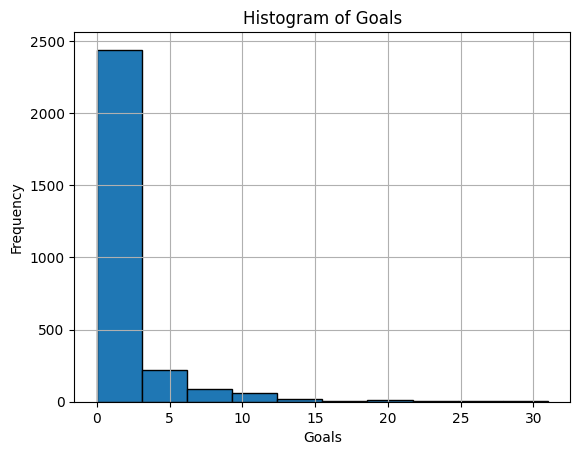

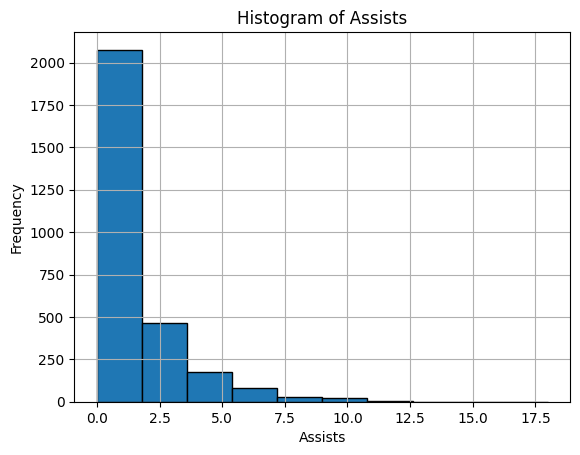

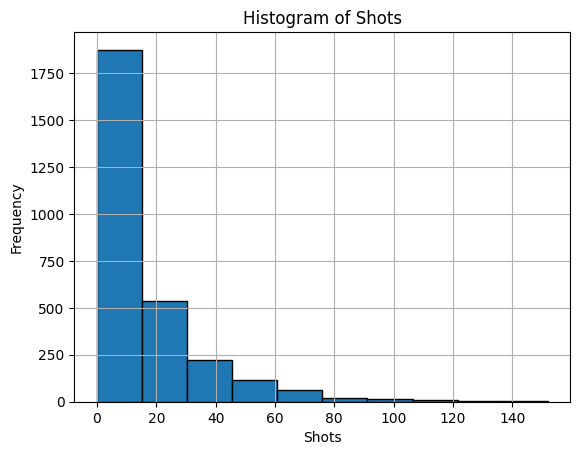

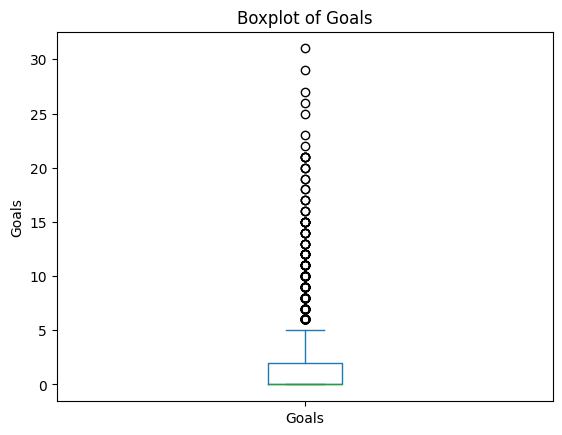

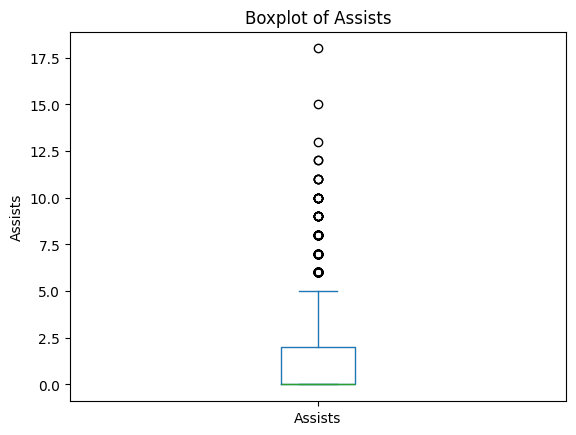

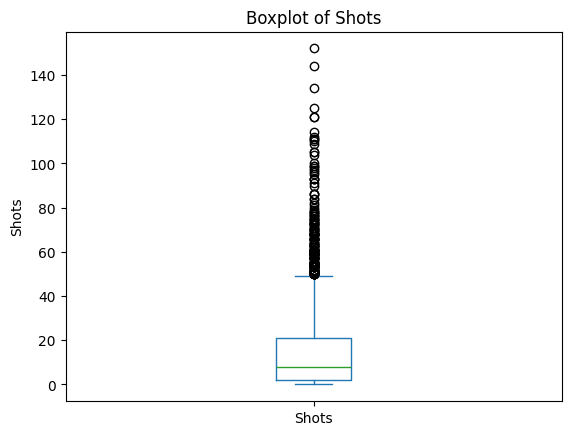

In [3]:
# Task 2: Univariate analysis (Histogram + Boxplot)
for col in ['Goals', 'Assists', 'Shots']:
    plt.figure()
    df[col].hist(bins=10, edgecolor='black')
    plt.title(f'Histogram of {col}')
    plt.xlabel(col)
    plt.ylabel('Frequency')
    plt.show()

for col in ['Goals', 'Assists', 'Shots']:
    plt.figure()
    df[col].plot(kind='box')
    plt.title(f'Boxplot of {col}')
    plt.ylabel(col)
    plt.show()

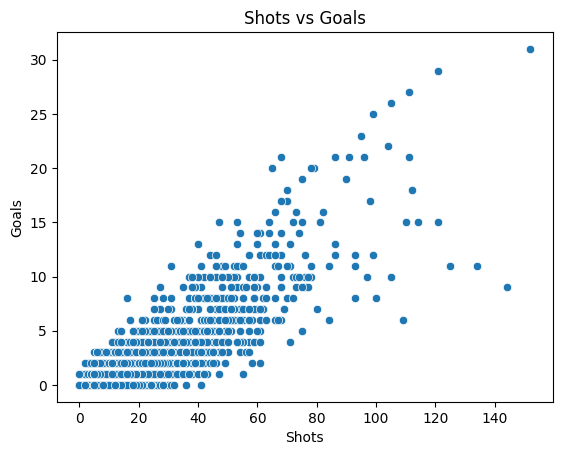

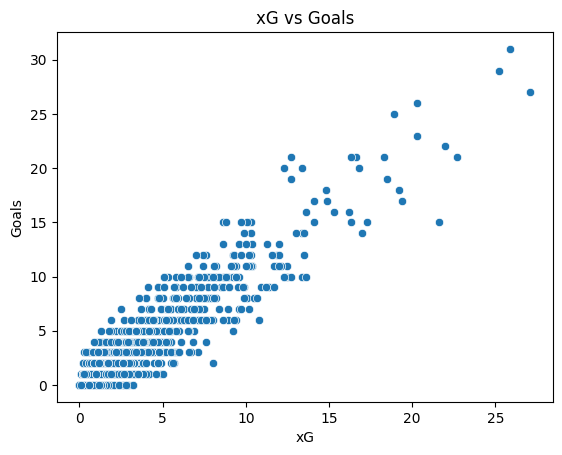

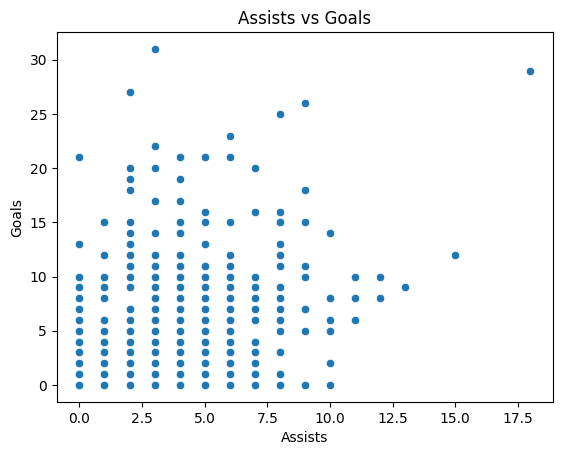

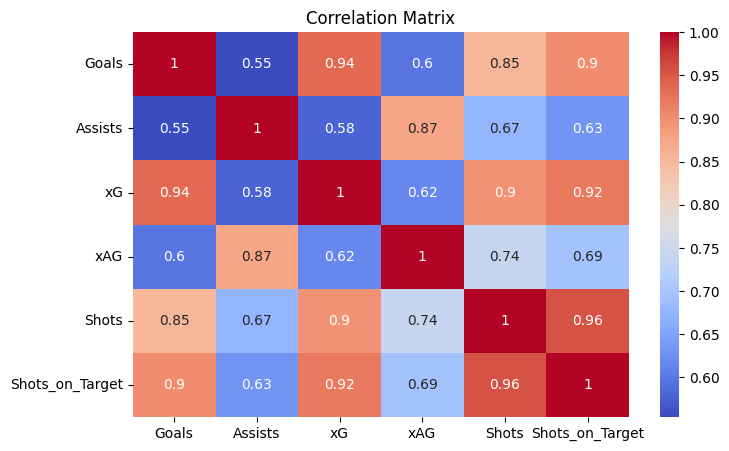

In [4]:
# Task 3: Bivariate + correlation heatmap
plt.figure()
sns.scatterplot(x=df['Shots'], y=df['Goals'])
plt.title('Shots vs Goals')
plt.xlabel('Shots')
plt.ylabel('Goals')
plt.show()

plt.figure()
sns.scatterplot(x=df['xG'], y=df['Goals'])
plt.title('xG vs Goals')
plt.xlabel('xG')
plt.ylabel('Goals')
plt.show()

plt.figure()
sns.scatterplot(x=df['Assists'], y=df['Goals'])
plt.title('Assists vs Goals')
plt.xlabel('Assists')
plt.ylabel('Goals')
plt.show()

plt.figure(figsize=(8, 5))
sns.heatmap(df[['Goals', 'Assists', 'xG', 'xAG', 'Shots', 'Shots_on_Target']].corr(), annot=True, cmap='coolwarm')
plt.title('Correlation Matrix')
plt.show()

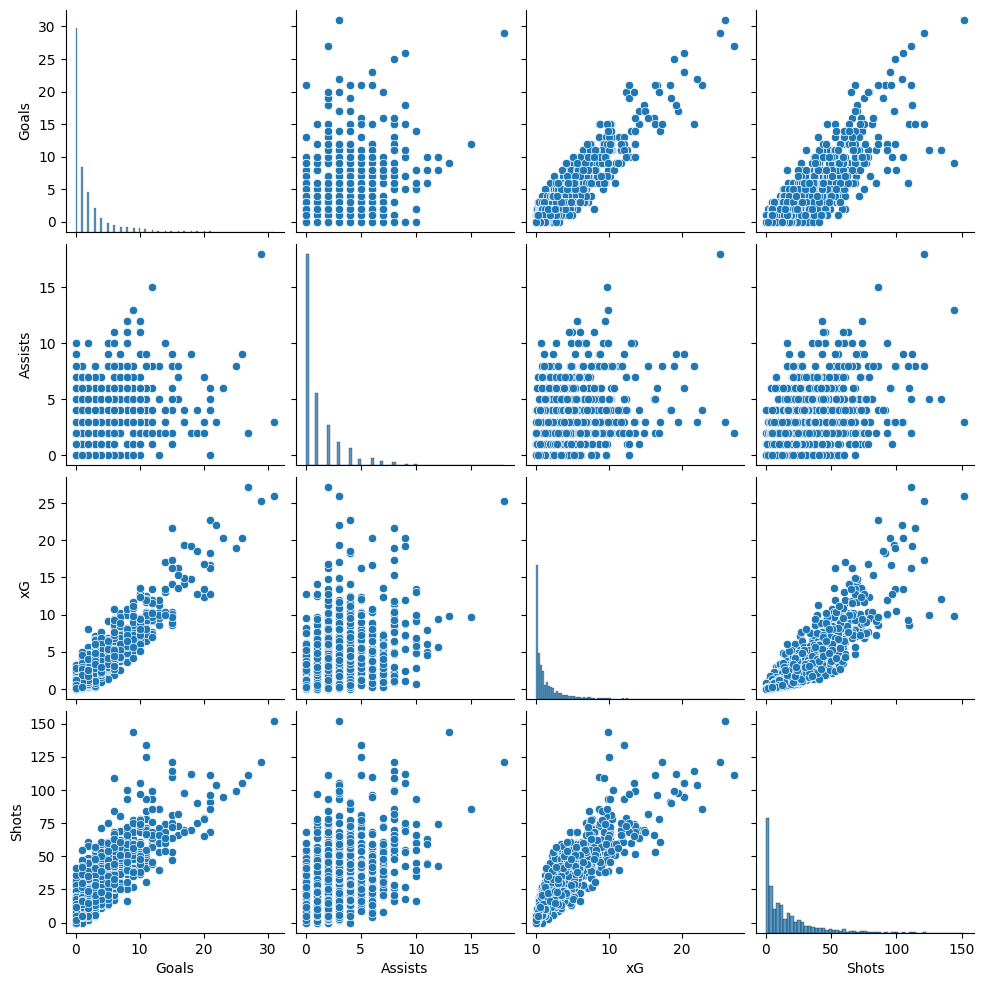

In [5]:
#multivariate analysis (pairplot)
sns.pairplot(df[['Goals', 'Assists', 'xG', 'Shots']])
plt.show()


Missing Values:
Player             0
Age                8
Position           0
Team               0
Matches            0
Minutes            0
Goals              0
Assists            0
xG                 0
xAG                0
Shots              0
Shots_on_Target    0
dtype: int64


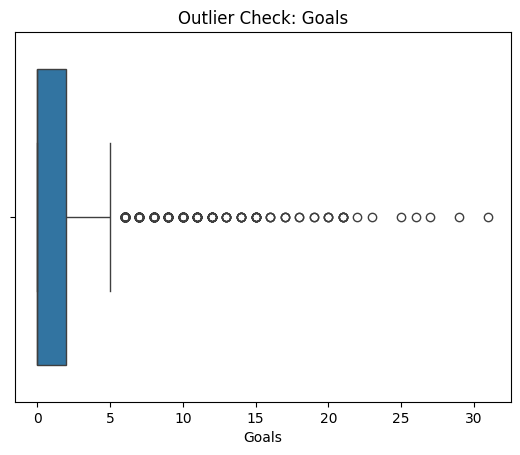

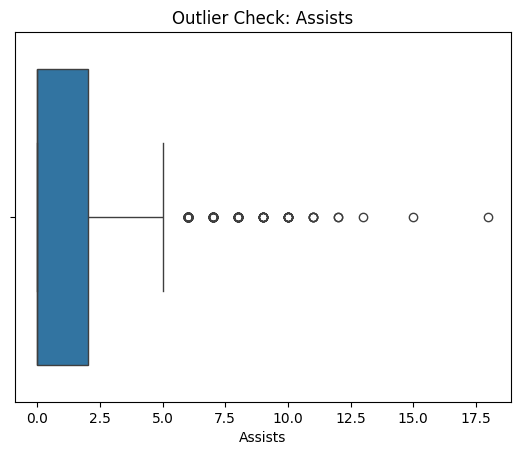

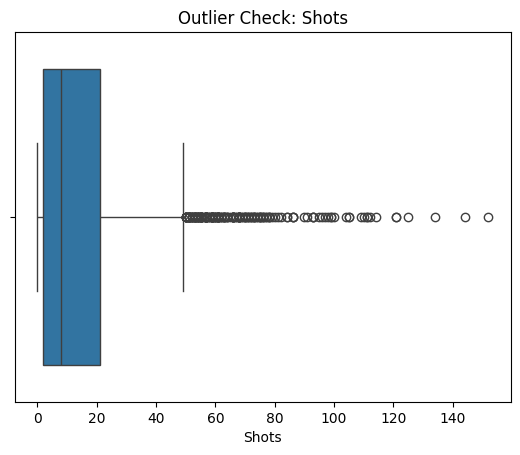

In [6]:
# Task 5: Missing data handling and outliers
print('\nMissing Values:')
print(df.isnull().sum())

df_clean = df.copy()
#missing data handling with median for numerical columns
num_cols = ['Age', 'Matches', 'Minutes', 'Goals', 'Assists', 'xG', 'xAG', 'Shots', 'Shots_on_Target']
for col in num_cols:
    df_clean[col] = df_clean[col].fillna(df_clean[col].median())
#categorical with mode....
for col in ['Player', 'Position', 'Team']:
    if df_clean[col].isnull().sum() > 0:
        df_clean[col] = df_clean[col].fillna(df_clean[col].mode()[0])
#outlier handling...
for col in ['Goals', 'Assists', 'Shots']:
    plt.figure()
    sns.boxplot(x=df_clean[col])
    plt.title(f'Outlier Check: {col}')
    plt.show()


Stats for Goals
Mean: 1.6829011913104415
Median: 0.0
Std: 3.1527323940659855
Skew: 3.474544523329327
Kurtosis: 16.57311602910211


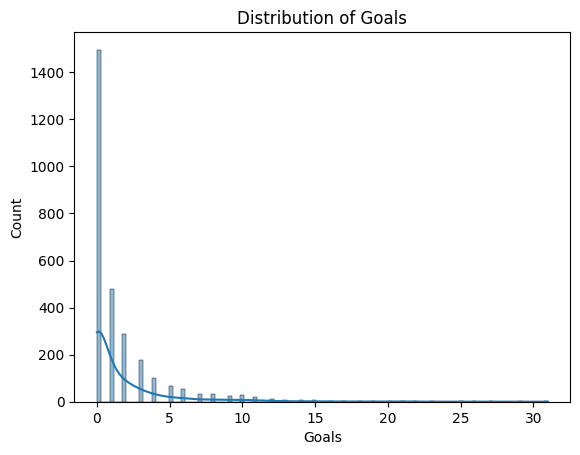

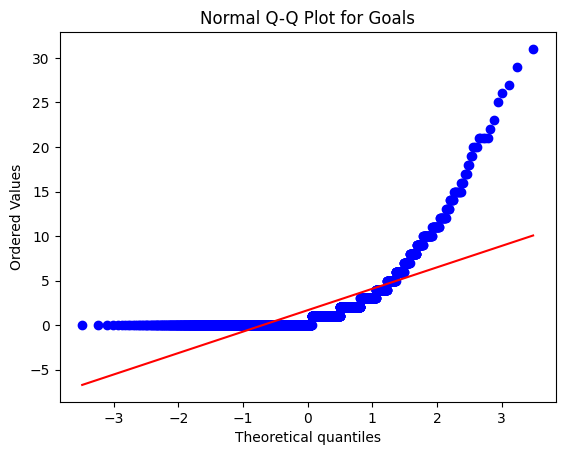


Stats for Assists
Mean: 1.200770847932726
Median: 0.0
Std: 1.946169929288784
Skew: 2.4344580903067436
Kurtosis: 7.78210209694768


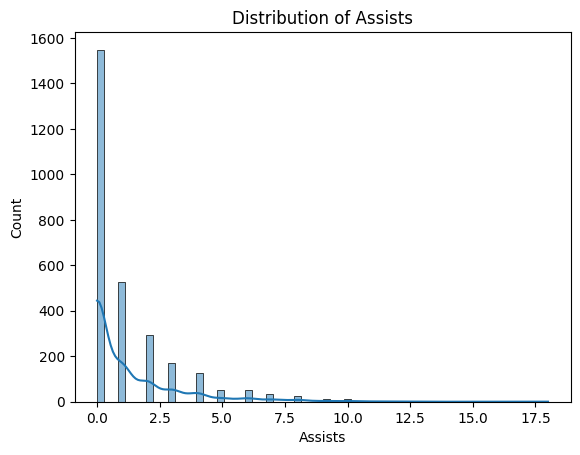

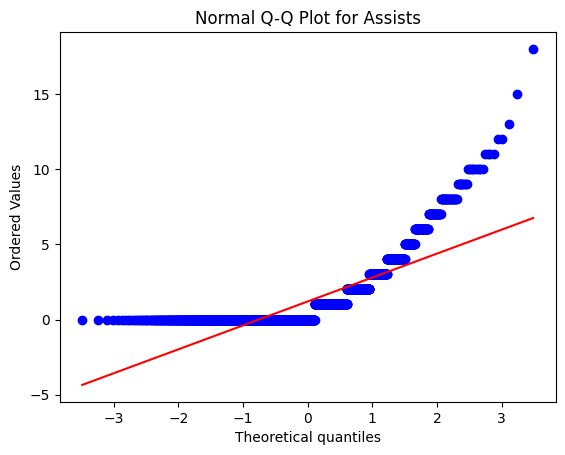


Stats for Shots
Mean: 15.121583742116329
Median: 8.0
Std: 19.024020553596294
Skew: 2.2015743144956494
Kurtosis: 6.545387294101541


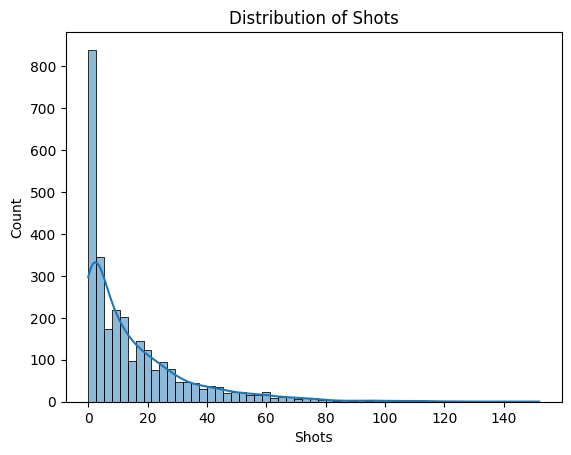

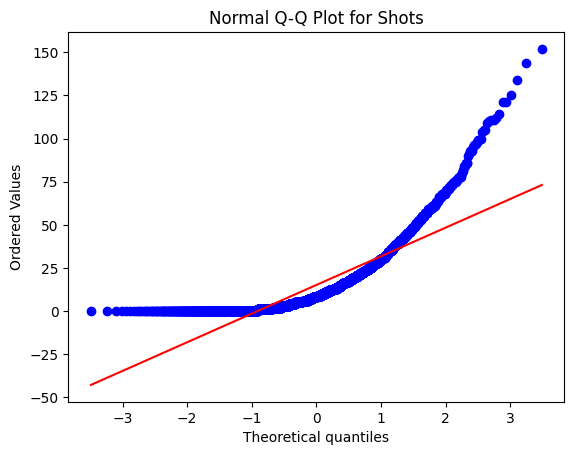

In [7]:
 # Task 6: Spread of data (mean, median, std, skew, kurtosis)
def spread(col):
    x = df_clean[col]
    print(f'\nStats for {col}')
    print('Mean:', x.mean())
    print('Median:', x.median())
    print('Std:', x.std())
    print('Skew:', x.skew())
    print('Kurtosis:', x.kurtosis())

    sns.histplot(x, kde=True)
    plt.title(f'Distribution of {col}')
    plt.show()

    stats.probplot(x, dist='norm', plot=plt)
    plt.title(f'Normal Q-Q Plot for {col}')
    plt.show()

for col in ['Goals', 'Assists', 'Shots']:
    spread(col)

In [8]:
# Task 7: Automating EDA using functions
def auto_eda(data):
    print('\n===== AUTO EDA =====')
    print(data.describe())
    print('\nInfo:')
    data.info()
    print('\nMissing Values:\n', data.isnull().sum())
    print('\nCorrelation:\n', data.corr(numeric_only=True))

auto_eda(df_clean)


===== AUTO EDA =====
               Age      Matches      Minutes        Goals      Assists  \
count  2854.000000  2854.000000  2854.000000  2854.000000  2854.000000   
mean     25.018921    19.012964  1211.529082     1.682901     1.200771   
std       4.485322    11.502122   965.191628     3.152732     1.946170   
min      15.000000     1.000000     1.000000     0.000000     0.000000   
25%      22.000000     9.000000   317.250000     0.000000     0.000000   
50%      25.000000    20.000000  1052.500000     0.000000     0.000000   
75%      28.000000    30.000000  1996.750000     2.000000     2.000000   
max      41.000000    38.000000  3420.000000    31.000000    18.000000   

                xG          xAG        Shots  Shots_on_Target  
count  2854.000000  2854.000000  2854.000000      2854.000000  
mean      1.706903     1.215662    15.121584         5.050105  
std       2.817612     1.686875    19.024021         7.406618  
min       0.000000     0.000000     0.000000         0.

In [9]:
# Task 8: Regression analysis (Simple Linear Regression)
# Make this cell robust even if the cleaning cell has not been run yet.
if 'df_clean' not in globals():
    if 'df' not in globals():
        df = pd.read_csv('cleaned_football_dataset.csv')
    df_clean = df.copy()
    num_cols = ['Age', 'Matches', 'Minutes', 'Goals', 'Assists', 'xG', 'xAG', 'Shots', 'Shots_on_Target']
    for col in num_cols:
        df_clean[col] = df_clean[col].fillna(df_clean[col].median())

X_simple = df_clean[['xG']]
y = df_clean['Goals']

model_simple = LinearRegression()
model_simple.fit(X_simple, y)

pred_simple = model_simple.predict(X_simple)

print('\nSimple Linear Regression')
print('Slope:', model_simple.coef_)
print('Intercept:', model_simple.intercept_)
print('MSE:', mean_squared_error(y, pred_simple))
print('MAE:', mean_absolute_error(y, pred_simple))
print('R2 Score:', r2_score(y, pred_simple))

print('\nCovariance (xG, Goals):')
print(df_clean[['xG', 'Goals']].cov())

print('\nCorrelation (xG, Goals):')
print(df_clean[['xG', 'Goals']].corr())


Simple Linear Regression
Slope: [1.04800277]
Intercept: -0.10593745221763995
MSE: 1.2198790321617876
MAE: 0.6689357195426064
R2 Score: 0.8772292962287894

Covariance (xG, Goals):
             xG     Goals
xG     7.938939  8.320030
Goals  8.320030  9.939722

Correlation (xG, Goals):
             xG     Goals
xG     1.000000  0.936605
Goals  0.936605  1.000000


In [10]:
# Task 9: Train/Test split and Multiple Linear Regression
X_multi = df_clean[['Age', 'Matches', 'Minutes', 'Assists', 'xG', 'xAG', 'Shots', 'Shots_on_Target']]
y_multi = df_clean['Goals']

X_train, X_test, y_train, y_test = train_test_split(X_multi, y_multi, test_size=0.2, random_state=42)

model_multi = LinearRegression()
model_multi.fit(X_train, y_train)

y_pred_train = model_multi.predict(X_train)
y_pred_test = model_multi.predict(X_test)

print('\nMultiple Linear Regression')
print('Train R2:', r2_score(y_train, y_pred_train))
print('Test R2:', r2_score(y_test, y_pred_test))
print('Test MSE:', mean_squared_error(y_test, y_pred_test))
print('Test MAE:', mean_absolute_error(y_test, y_pred_test))


Multiple Linear Regression
Train R2: 0.8917173402139974
Test R2: 0.9064024521910452
Test MSE: 1.01722745419579
Test MAE: 0.5854143750522729


In [11]:
# Task 10: Classification task using Logistic Regression
threshold = df_clean['Goals'].median()
df_clean['Goal_Class'] = df_clean['Goals'].apply(lambda x: 1 if x > threshold else 0)

print('\nClass Distribution:')
print(df_clean['Goal_Class'].value_counts())

X_cls = df_clean[['Age', 'Matches', 'Minutes', 'Assists', 'xG', 'xAG', 'Shots', 'Shots_on_Target']]
y_cls = df_clean['Goal_Class']

X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(
    X_cls, y_cls, test_size=0.2, random_state=42, stratify=y_cls
)

clf = LogisticRegression(max_iter=1000)
clf.fit(X_train_c, y_train_c)

y_pred_c = clf.predict(X_test_c)

print('\nClassification Results')
print('Accuracy:', accuracy_score(y_test_c, y_pred_c))
print('Confusion Matrix:\n', confusion_matrix(y_test_c, y_pred_c))
print('Classification Report:\n', classification_report(y_test_c, y_pred_c))


Class Distribution:
Goal_Class
0    1496
1    1358
Name: count, dtype: int64

Classification Results
Accuracy: 0.8739054290718039
Confusion Matrix:
 [[271  28]
 [ 44 228]]
Classification Report:
               precision    recall  f1-score   support

           0       0.86      0.91      0.88       299
           1       0.89      0.84      0.86       272

    accuracy                           0.87       571
   macro avg       0.88      0.87      0.87       571
weighted avg       0.87      0.87      0.87       571



In [12]:
# Task 11: Final evaluation summary
mse_simple = mean_squared_error(y, pred_simple)
mae_simple = mean_absolute_error(y, pred_simple)
r2_simple = r2_score(y, pred_simple)

print('\n===== SIMPLE LINEAR REGRESSION EVALUATION =====')
print('MSE:', mse_simple)
print('MAE:', mae_simple)
print('R2 Score:', r2_simple)





===== SIMPLE LINEAR REGRESSION EVALUATION =====
MSE: 1.2198790321617876
MAE: 0.6689357195426064
R2 Score: 0.8772292962287894


In [13]:
# ===== TRAIN THE MODEL =====

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

# Independent variables (features) for match goal prediction
match_feature_cols = ["Shots", "xG", "Matches"]
X = df[match_feature_cols]

# Target variable
y = df["Goals"]

# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Create model
model = LinearRegression()

# Train model
model.fit(X_train, y_train)

print("Model trained successfully")
print("Features:", match_feature_cols)

Model trained successfully
Features: ['Shots', 'xG', 'Matches']


In [14]:

# ===== USER INPUT: GOAL + MATCH OUTCOME PREDICTION =====

import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

# Make this cell self-contained if training cells were not run
if 'df' not in globals():
    df = pd.read_csv('cleaned_football_dataset.csv')

# Use a dedicated feature list for this task to avoid variable collisions
match_feature_cols = ["Shots", "xG", "Matches"]

# Retrain model if missing or trained on a different feature set
needs_retrain = (
    'model' not in globals()
    or not hasattr(model, 'feature_names_in_')
    or list(model.feature_names_in_) != match_feature_cols
)

if needs_retrain:
    X = df[match_feature_cols]
    y = df["Goals"]
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42
    )
    model = LinearRegression()
    model.fit(X_train, y_train)


def get_float_input(prompt_text):
    while True:
        raw_value = input(prompt_text).strip()
        if raw_value == '':
            print('Input cannot be empty. Please enter a number.')
            continue
        try:
            return float(raw_value)
        except ValueError:
            print('Invalid number. Please try again.')


try:
    # Home team inputs
    home_shots = get_float_input("Enter HOME team shots: ")
    home_xg = get_float_input("Enter HOME team expected goals (xG): ")
    home_matches = get_float_input("Enter HOME team matches played: ")

    # Away team inputs
    away_shots = get_float_input("Enter AWAY team shots: ")
    away_xg = get_float_input("Enter AWAY team expected goals (xG): ")
    away_matches = get_float_input("Enter AWAY team matches played: ")

    # Build input frames with the same feature names used in training
    home_data = pd.DataFrame([[home_shots, home_xg, home_matches]], columns=match_feature_cols)
    away_data = pd.DataFrame([[away_shots, away_xg, away_matches]], columns=match_feature_cols)

    # Predict goals for each team
    pred_home_goals = float(model.predict(home_data)[0])
    pred_away_goals = float(model.predict(away_data)[0])

    # Clip at 0 because goals cannot be negative
    pred_home_goals = max(0.0, pred_home_goals)
    pred_away_goals = max(0.0, pred_away_goals)

    # Decide outcome
    if pred_home_goals > pred_away_goals:
        outcome = "Home Win"
    elif pred_home_goals < pred_away_goals:
        outcome = "Away Win"
    else:
        outcome = "Draw"

    print("\nPredicted Home Goals:", round(pred_home_goals, 2))
    print("Predicted Away Goals:", round(pred_away_goals, 2))
    print("Predicted Match Outcome:", outcome)

except KeyboardInterrupt:
    print("\nPrediction cancelled.")



Predicted Home Goals: 3.87
Predicted Away Goals: 4.78
Predicted Match Outcome: Away Win


In [15]:

# ===== SIMPLE PLAYER GOAL PREDICTION (MINOR PROJECT) =====

import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

# Make this cell self-contained
if 'df' not in globals():
    df = pd.read_csv('cleaned_football_dataset.csv')


def encode_position(position_value):
    position_text = str(position_value).upper()
    if 'FW' in position_text:
        return 3
    if 'MF' in position_text:
        return 2
    if 'DF' in position_text:
        return 1
    return 0


def get_float_input(prompt_text):
    while True:
        raw_value = input(prompt_text).strip()
        if raw_value == '':
            print('Input cannot be empty. Please enter a number.')
            continue
        try:
            return float(raw_value)
        except ValueError:
            print('Invalid number. Please try again.')


def get_position_input(prompt_text):
    valid_positions = ['FW', 'MF', 'DF', 'GK']
    while True:
        position_value = input(prompt_text).strip().upper()
        if position_value == '':
            print('Position cannot be empty. Please enter FW, MF, DF, or GK.')
            continue
        if position_value not in valid_positions:
            print(f'Invalid position. Please enter one of: {", ".join(valid_positions)}')
            continue
        return position_value


player_df = df.copy()

for col in ['Age', 'Matches', 'Minutes', 'Goals', 'Assists', 'xAG', 'Shots']:
    player_df[col] = player_df[col].fillna(player_df[col].median())

if player_df['Position'].isnull().sum() > 0:
    player_df['Position'] = player_df['Position'].fillna(player_df['Position'].mode()[0])

player_df['Position_Code'] = player_df['Position'].apply(encode_position)

player_feature_cols = ['Age', 'Position_Code', 'Matches', 'Minutes', 'Assists', 'xAG', 'Shots']
X = player_df[player_feature_cols]
y = player_df['Goals']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

player_model = LinearRegression()
player_model.fit(X_train, y_train)

try:
    age = get_float_input('Enter player age: ')
    position = get_position_input('Enter player position (FW/MF/DF/GK): ')
    matches = get_float_input('Enter total matches played: ')
    minutes = get_float_input('Enter total minutes played: ')
    assists = get_float_input('Enter player assists: ')
    xag = get_float_input('Enter player xAG: ')
    shots = get_float_input('Enter player shots: ')

    player_input = pd.DataFrame([[
        age,
        encode_position(position),
        matches,
        minutes,
        assists,
        xag,
        shots
    ]], columns=player_feature_cols)

    predicted_goals = float(player_model.predict(player_input)[0])
    predicted_goals = max(0.0, predicted_goals)

    print('Predicted goals is', round(predicted_goals, 2))

except KeyboardInterrupt:
    print("\nPrediction cancelled.")


Predicted goals is 3.9
